## ¿Qué tipo de delito domina por departamento y cómo varía por año?

Los departamentos presentan perfiles criminales distintos. Se asume que las zonas urbanas y metropolitanas tendrán mayor peso en delitos contra la seguridad y el patrimonio (robos), mientras que en zonas rurales u occidentales predominarán los delitos contra la vida, integridad y libertad sexual.

Cargando datos de VIF...

--- Perfil de Violencia por Departamento (Top 3 Tipos) ---
Tipos de violencia dominantes (% del total en el depto):
- Alta Verapaz: Psicologica (38.7%), Fisica psicologica (36.4%), Fisica (13.2%)
- Baja Verapaz: Psicologica (45.4%), Fisica psicologica (34.9%), Fisica (10.1%)
- Chimaltenango: Psicologica (38.3%), Fisica psicologica (37.4%), Fisica (8.7%)
- Chiquimula: Psicologica (41.6%), Fisica psicologica (31.3%), Fisica (10.1%)
- El Progreso: Psicologica (49.8%), Fisica psicologica (31.6%), Psicologica patrimonial (6.3%)
- Escuintla: Fisica psicologica (46.7%), Psicologica (32.7%), Fisica (11.3%)
- Guatemala: Psicologica (49.1%), Fisica psicologica (27.4%), Fisica (8.1%)
- Huehuetenango: Fisica psicologica (37.6%), Psicologica (27.1%), Fisica (16.4%)
- Izabal: Fisica psicologica (46.8%), Psicologica (33.6%), Fisica psicologica patrimonial (9.6%)
- Jalapa: Psicologica (50.0%), Fisica psicologica (33.8%), Fisica (9.2%)
- Jutiapa: Psicologica (49.9%), Fisica ps

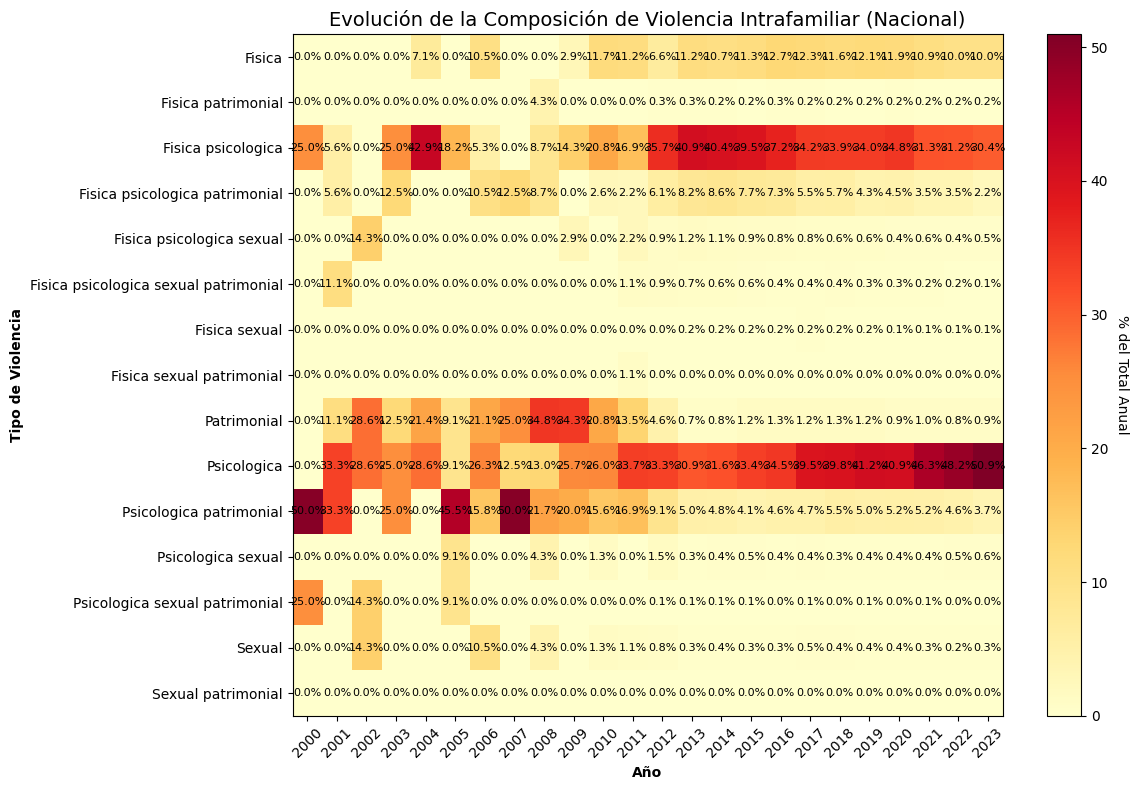

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# ---------------------------------------------------------
# CONFIGURACIÓN DEL ENTORNO (Busca data_pipeline dinámicamente)
# ---------------------------------------------------------
project_root = Path.cwd()
while not (project_root / 'data_pipeline.py').exists():
    if project_root.parent == project_root:
        raise FileNotFoundError("No se encontró data_pipeline.py")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
import data_pipeline as dp
# ---------------------------------------------------------
# 1. CARGA Y PREPARACIÓN DE DATOS
# ---------------------------------------------------------
print("Cargando datos de VIF...")
try:
    # Usamos only_common_years=False para tener todo el historial de VIF
    df = dp.build_panel(force_rebuild=False, only_common_years=False)
except Exception as e:
    print(f"Error cargando datos: {e}")
    raise
# Identificamos las columnas de tipos de violencia (prefijo 'vif_tipo_')
tipo_cols = [col for col in df.columns if col.startswith('vif_tipo_')]
if not tipo_cols:
    print("Error: No se encontraron columnas de tipos de violencia (vif_tipo_*)")
else:
    # Filtramos filas con datos válidos en departamento y año
    df_vif = df.dropna(subset=['departamento', 'anio']).copy()
    
    # Rellenamos nulos con 0 y aseguramos enteros
    df_vif[tipo_cols] = df_vif[tipo_cols].fillna(0).astype(int)
    # ---------------------------------------------------------
    # 2. PERFIL CRIMINAL POR DEPARTAMENTO (Tabla de Proporciones)
    # ---------------------------------------------------------
    print("\n--- Perfil de Violencia por Departamento (Top 3 Tipos) ---")
    # Agrupamos por departamento y sumamos los tipos de violencia
    depto_tipo = df_vif.groupby('departamento')[tipo_cols].sum()
    
    # Calculamos el total de casos por departamento para sacar porcentajes
    depto_total = depto_tipo.sum(axis=1)
    
    # Convertimos a porcentajes (proporciones)
    depto_prop = depto_tipo.div(depto_total, axis=0) * 100
    # Limpiamos nombres de columnas para visualización (quitamos 'vif_tipo_')
    depto_prop.columns = [c.replace('vif_tipo_', '').replace('_', ' ').capitalize() for c in depto_prop.columns]
    # Mostramos los 3 tipos dominantes por departamento
    print("Tipos de violencia dominantes (% del total en el depto):")
    for depto in depto_prop.index:
        top_3 = depto_prop.loc[depto].nlargest(3)
        top_str = ", ".join([f"{idx} ({val:.1f}%)" for idx, val in top_3.items()])
        print(f"- {depto}: {top_str}")
    # ---------------------------------------------------------
    # 3. HEATMAP TEMPORAL (Evolución de Tipos)
    # ---------------------------------------------------------
    print("\n--- Generando Heatmap Temporal ---")
    # Agrupamos por año y tipo de violencia a nivel nacional
    anio_tipo = df_vif.groupby('anio')[tipo_cols].sum()
    
    # Renombramos columnas igual que antes
    anio_tipo.columns = [c.replace('vif_tipo_', '').replace('_', ' ').capitalize() for c in anio_tipo.columns]
    # Normalizamos por año (para ver la composición % de cada año)
    # Opcional: Si prefieres ver volumen absoluto, comenta la siguiente línea
    anio_prop = anio_tipo.div(anio_tipo.sum(axis=1), axis=0) * 100
    # Crear Heatmap manual con Matplotlib
    plt.figure(figsize=(12, 8))
    
    # Matriz de datos
    data_values = anio_prop.values.T  # Transponemos para que Y=Tipos, X=Años
    x_labels = anio_prop.index
    y_labels = anio_prop.columns
    # Mapa de calor
    im = plt.imshow(data_values, cmap='YlOrRd', aspect='auto')
    # Configuración de ejes
    plt.xticks(np.arange(len(x_labels)), x_labels, rotation=45)
    plt.yticks(np.arange(len(y_labels)), y_labels)
    # Barra de color
    cbar = plt.colorbar(im)
    cbar.set_label('% del Total Anual', rotation=270, labelpad=15)
    # Etiquetas de valores en las celdas
    for i in range(len(y_labels)):
        for j in range(len(x_labels)):
            text = plt.text(j, i, f"{data_values[i, j]:.1f}%",
                           ha="center", va="center", color="black", fontsize=8)
    plt.title('Evolución de la Composición de Violencia Intrafamiliar (Nacional)', fontsize=14)
    plt.xlabel('Año', fontweight='bold')
    plt.ylabel('Tipo de Violencia', fontweight='bold')
    plt.tight_layout()
    plt.show()